# GET MNIST Data

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784",as_frame=False)

'''
The sklearn.datasets package contains mostly three types of functions: fetch_* functions
such as fetch_openml() to download real-life datasets, load_* functions to load small toy
datasets bundled with Scikit-Learn (so they don’t need to be downloaded over the internet), and
make_* functions to generate fake datasets, useful for tests
'''

'\nThe sklearn.datasets package contains mostly three types of functions: fetch_* functions \nsuch as fetch_openml() to download real-life datasets, load_* functions to load small toy \ndatasets bundled with Scikit-Learn (so they don’t need to be downloaded over the internet), and \nmake_* functions to generate fake datasets, useful for tests\n'

In [2]:
# it Returns the input in Pandas Dataframe and Label in Pandas in Series
X,y = mnist.data,mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [3]:
X.shape

(70000, 784)

In [4]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [5]:
y.shape

(70000,)

### Each Image has 784 Features as each image is 28x28 pixels lets see one of the image

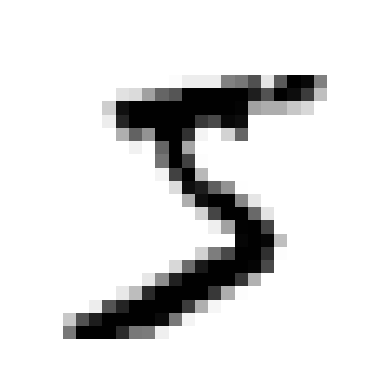

In [6]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
  image = image_data.reshape(28,28)
  plt.imshow(image,cmap="binary") # for black and white so binary
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
y[0]

'5'

### So it was 5

In [8]:
# our data is already split from fetch_openmal()

X_train,X_test,y_train,y_test = X[:60000],X[60000:],y[:60000],y[60000:]


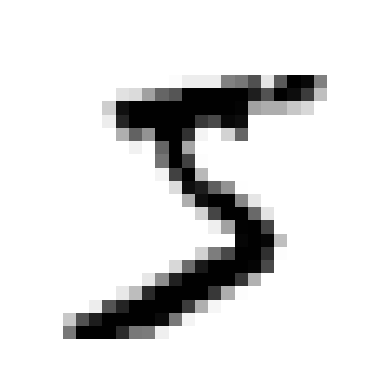

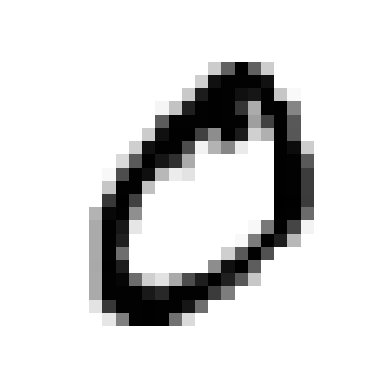

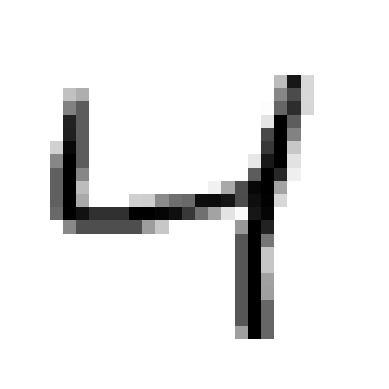

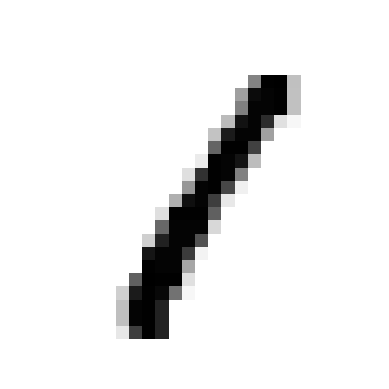

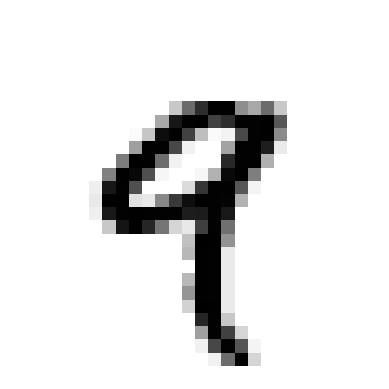

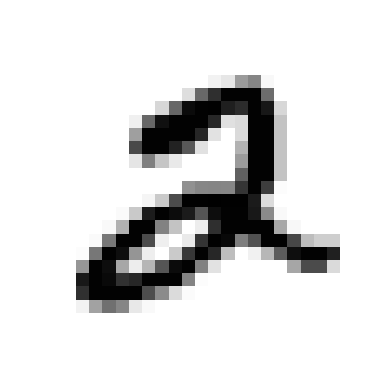

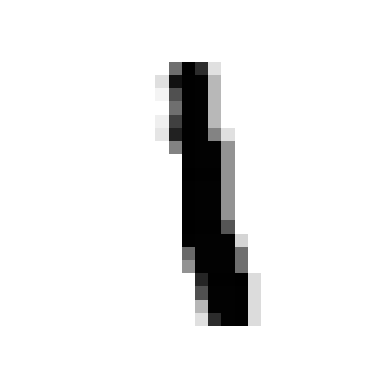

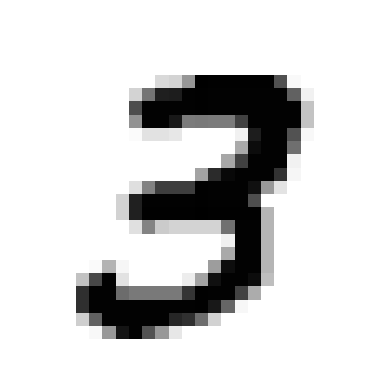

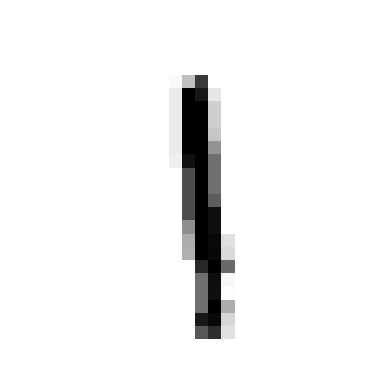

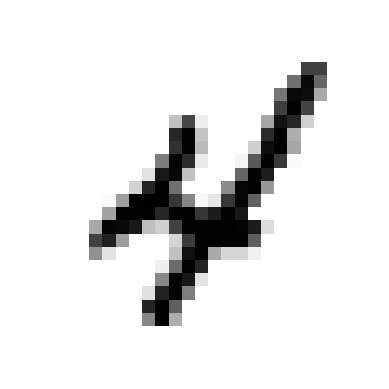

In [9]:
for (i,data) in enumerate(X_train[:10]):
  plot_digit(data)
  plt.show()


# Training a Binary Classifier

### we will simplipy the problem and try to check only one digit 5-detctor is it 5 or not 5

In [10]:
y_train_5 = (y_train == '5') # return True for indexs were element is 5 else false
y_test_5 = (y_test == '5')
y_train_5

array([ True, False, False, ...,  True, False, False])

In [11]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

### Now Lets test the model that does it can detect 5

In [19]:
sgd_clf.predict(X_train[:50])

array([ True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True, False])

In [20]:
y_train[:50]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4', '3', '5', '3',
       '6', '1', '7', '2', '8', '6', '9', '4', '0', '9', '1', '1', '2',
       '4', '3', '2', '7', '3', '8', '6', '9', '0', '5', '6', '0', '7',
       '6', '1', '8', '7', '9', '3', '9', '8', '5', '9', '3'],
      dtype=object)

# Performance Measures

#### often Evaluating a Classifier is Much Tricker than Evaluating a Regressor

## Measuring Accuracy using Cross-Validation